- Ce script réalise une analyse approfondie de données d'enquête sur la pauvreté en Côte d'Ivoire (EHCVM 2021-2022), traitant à la fois des données socio-économiques et géographiques. Le processus commence par le chargement de deux fichiers Stata : un fichier principal contenant les informations socio-économiques des ménages (ehcvm_welfare_2b_CIV2021.dta) et un fichier avec leurs coordonnées GPS (s00_me_CIV2021.dta). Une exploration initiale est effectuée pour comprendre la structure des données, affichant les colonnes, dimensions et caractéristiques de chaque DataFrame.

- La fusion des données est réalisée sur trois variables clés : 'vague', 'grappe', et 'menage', permettant d'associer les coordonnées GPS à chaque ménage tout en préservant l'intégralité des données socio-économiques. Le script procède ensuite à un nettoyage méticuleux en identifiant, comptabilisant et supprimant les entrées avec des coordonnées GPS manquantes pour garantir la qualité des analyses géographiques ultérieures.

- Un élément central du script est la création de la variable binaire 'pcexp_binaire' qui catégorise les ménages comme pauvres (1) ou non pauvres (0) en comparant leurs dépenses par habitant (pcexp) au seuil de pauvreté national (zref) fixé à 369,516.46875 Francs CFA. Cette classification est fondamentale pour les analyses de pauvreté qui suivent.

- L'analyse exploratoire des données (EDA) est particulièrement exhaustive, utilisant diverses techniques de visualisation et d'analyse statistique : analyse des valeurs manquantes, calcul de statistiques descriptives, création de matrices de corrélation, visualisation des distributions par histogrammes, analyse des variables catégorielles, détection d'outliers via des box plots, et visualisation géographique des ménages sur une carte administrative de la Côte d'Ivoire avec geopandas.

- La conclusion du script est marquée par le calcul du taux de pauvreté national, utilisant une méthodologie sophistiquée qui prend en compte à la fois la taille des ménages (hhsize) et les pondérations de l'enquête (hhweight). Cette approche pondérée assure une estimation représentative et précise du taux de pauvreté au niveau national. Les résultats sont présentés sous forme de pourcentage et l'ensemble des données traitées est sauvegardé dans un fichier CSV pour permettre des analyses ultérieures.

In [1]:
# On charge les bibliothèques nécessaires
import pandas as pd
import numpy as np
import os

- La version finale des données de l'EHCVM sont données par le fichier "ehcvm_welfare_2b_CIV2021.dta" 

In [2]:
#Chargement des données d'enquetes
df_base =pd.read_stata(r'D:\wealth_predict_2021\data\DATA_EHCVM_2021_2022\Dataout\ehcvm_welfare_2b_CIV2021.dta')
df_gps =pd.read_stata(r'D:\wealth_predict_2021\data\DATA_EHCVM_2021_2022\Datain\Menage\s00_me_CIV2021.dta')

In [3]:
for column in df_base:
    print(column)

country
year
hhid
grappe
menage
vague
zae
region
milieu
hhweight
hhsize
eqadu1
eqadu2
hgender
hage
hmstat
hreligion
hnation
hethnie
halfa
halfa2
heduc
hdiploma
hhandig
hactiv7j
hactiv12m
hbranch
hsectins
hcsp
dali
dnal
dtot
pcexp
zref
def_spa
def_temp


In [4]:
for column in df_gps:
    print(column)

interview__key
interview__id
vague
grappe
menage
gps__latitude
gps__longitude
gps__accuracy
gps__altitude
gps__timestamp
nom_prenom_cm
s1q7
s1q9
s1q10
localisation_menage
latitude_denomb
longitude_denomb
statut_tirage
anneescolaireencours
anneescolairepassee
campagneagricole
s00q00
s00q01
s00q02
s00q03
s00q04
s00q05
s00q05_label
aut_localite
s00q06
s00q07
s00q08
s00q09
s00q07a
s00q07b
s00q07c
s00q07d
s00q07e
s00q07f1
s00q07f2
s00q10
s00q11
s00q12a
s00q12a1
s00q12b
s00q13a
s00q13
s00q14
s00q15a
s00q15
s00q16
s00q17a
s00q17
s00q18
s00q21
s00q20
s00q19
s00q22
visite1
s00q23a
visite2
s00q24a
visite3
s00q25a
exist_ancien_men
interview_key_enum
interview_key_search
interview_key_ehcvm2018
s00q23b
s00q24b
s00q25b
s00q28
s00q27
versionform
date_selection
panel


In [5]:
print(df_base.shape)
print(df_gps.shape)

(12965, 36)
(13693, 76)


In [6]:
df_base.head()

,country,year,hhid,grappe,menage,vague,zae,region,milieu,hhweight,...,hbranch,hsectins,hcsp,dali,dnal,dtot,pcexp,zref,def_spa,def_temp
0,CIV,2021,102.0,1,2,1,ABIDJAN,AUTONOME D'ABIDJAN,Urbain,1098.117188,...,Education/Sante,Entreprise Privée,Travailleur pour compte propre,2.461982e+06,2.218995e+06,4680977.500,6.064041e+05,369516.4375,1.102748,0.983505
1,CIV,2021,103.0,1,3,1,ABIDJAN,AUTONOME D'ABIDJAN,Urbain,1098.117188,...,Commerce,Entreprise Privée,Travailleur pour compte propre,8.467611e+05,8.632815e+05,1710042.625,5.169033e+05,369516.4375,1.102748,0.983505
2,CIV,2021,104.0,1,4,1,ABIDJAN,AUTONOME D'ABIDJAN,Urbain,1098.117188,...,Commerce,Entreprise Privée,Stagiaire ou Apprenti rénuméré,6.892256e+05,9.113361e+05,1600561.625,1.451430e+06,369516.4375,1.102748,0.983505
3,CIV,2021,105.0,1,5,1,ABIDJAN,AUTONOME D'ABIDJAN,Urbain,1098.117188,...,Commerce,Entreprise Privée,Travailleur pour compte propre,5.619840e+05,5.490956e+05,1111079.500,1.007555e+06,369516.4375,1.102748,0.983505
4,CIV,2021,106.0,1,6,1,ABIDJAN,AUTONOME D'ABIDJAN,Urbain,1098.117188,...,Commerce,Entreprise Privée,Travailleur pour compte propre,1.456851e+06,1.651458e+06,3108308.250,5.637385e+05,369516.4375,1.102748,0.983505


In [7]:
df_gps.head()

,interview__key,interview__id,vague,grappe,menage,gps__latitude,gps__longitude,gps__accuracy,gps__altitude,gps__timestamp,...,interview_key_search,interview_key_ehcvm2018,s00q23b,s00q24b,s00q25b,s00q28,s00q27,versionform,date_selection,panel
0,20-73-49-77,7b57741514614c48b38b3a08f65bbc9a,1.0,61,1.0,5.435473,-4.018662,23.720644,138.600891,2021-11-13T17:10:27,...,46-30-23-38,##N/A##,2021-11-13T17:48:07,2021-11-14T19:42:22,2021-11-15T13:03:59,Langue1,Complet,1.0,2021-11-12,Menage panel
1,20-44-20-63,7a1e5af66901449494001932150c979c,1.0,61,2.0,5.435541,-4.015984,14.259366,186.153320,2021-11-18T15:06:41,...,00-42-74-81,##N/A##,2021-11-17T19:50:35,2021-11-18T17:32:49,2021-11-18T20:21:16,Langue1,Complet,1.0,2021-11-12,Menage panel
2,69-37-13-21,a80b2a097df14348ac19ecd2131a59f8,1.0,61,3.0,5.435752,-4.016034,4.025751,139.624756,2021-11-18T13:16:19,...,,,##N/A##,,,NaN,NaN,1.0,2021-11-12,Menage panel
3,19-32-03-99,d0d3a92373d7484d90cb3ab8cf420845,1.0,61,4.0,5.435405,-4.016499,7.328885,143.921631,2021-11-18T13:52:59,...,,,##N/A##,,,NaN,NaN,1.0,2021-11-12,Menage panel
4,40-27-52-95,35fdb215f85947839c9284431512162d,1.0,61,5.0,5.435185,-4.017121,11.992245,139.673340,2021-11-18T11:15:00,...,,,2021-11-17T14:54:33,2021-11-17T14:54:34,2021-11-17T16:26:33,Langue1,Complet,1.0,2021-11-12,Menage non panel


In [8]:
print(df_base.info())
print(df_gps.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12965 entries, 0 to 12964
Data columns (total 36 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   country    12965 non-null  object  
 1   year       12965 non-null  int16   
 2   hhid       12965 non-null  float32 
 3   grappe     12965 non-null  int16   
 4   menage     12965 non-null  int8    
 5   vague      12965 non-null  int8    
 6   zae        12965 non-null  category
 7   region     12965 non-null  category
 8   milieu     12965 non-null  category
 9   hhweight   12965 non-null  float32 
 10  hhsize     12965 non-null  int8    
 11  eqadu1     12965 non-null  float64 
 12  eqadu2     12965 non-null  float32 
 13  hgender    12965 non-null  category
 14  hage       12965 non-null  int16   
 15  hmstat     12965 non-null  category
 16  hreligion  12965 non-null  category
 17  hnation    12965 non-null  category
 18  hethnie    10474 non-null  category
 19  halfa      12965 non-null

In [9]:
# Fusion des deux DataFrames sur les clés communes 'vague', 'grappe' et 'menage'
merged_df = pd.merge(
    df_base,
    df_gps[['vague', 'grappe', 'menage', 'gps__latitude', 'gps__longitude']],
    on=['vague', 'grappe', 'menage'],
    how='left'  # Utilisation de 'left' pour garder toutes les lignes de df_base
)



In [10]:

# Vérification du résultat
print(merged_df.head())
print(merged_df.shape)

  country  year   hhid  grappe  menage  vague      zae              region  \
0     CIV  2021  102.0       1       2      1  ABIDJAN  AUTONOME D'ABIDJAN   
1     CIV  2021  103.0       1       3      1  ABIDJAN  AUTONOME D'ABIDJAN   
2     CIV  2021  104.0       1       4      1  ABIDJAN  AUTONOME D'ABIDJAN   
3     CIV  2021  105.0       1       5      1  ABIDJAN  AUTONOME D'ABIDJAN   
4     CIV  2021  106.0       1       6      1  ABIDJAN  AUTONOME D'ABIDJAN   

   milieu     hhweight  ...                            hcsp          dali  \
0  Urbain  1098.117188  ...  Travailleur pour compte propre  2.461982e+06   
1  Urbain  1098.117188  ...  Travailleur pour compte propre  8.467611e+05   
2  Urbain  1098.117188  ...  Stagiaire ou Apprenti rénuméré  6.892256e+05   
3  Urbain  1098.117188  ...  Travailleur pour compte propre  5.619840e+05   
4  Urbain  1098.117188  ...  Travailleur pour compte propre  1.456851e+06   

           dnal         dtot         pcexp         zref   def_spa  d

In [11]:
# Les informations sur les données fusionées
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12965 entries, 0 to 12964
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   country         12965 non-null  object  
 1   year            12965 non-null  int16   
 2   hhid            12965 non-null  float32 
 3   grappe          12965 non-null  int16   
 4   menage          12965 non-null  int8    
 5   vague           12965 non-null  int8    
 6   zae             12965 non-null  category
 7   region          12965 non-null  category
 8   milieu          12965 non-null  category
 9   hhweight        12965 non-null  float32 
 10  hhsize          12965 non-null  int8    
 11  eqadu1          12965 non-null  float64 
 12  eqadu2          12965 non-null  float32 
 13  hgender         12965 non-null  category
 14  hage            12965 non-null  int16   
 15  hmstat          12965 non-null  category
 16  hreligion       12965 non-null  category
 17  hnation     

In [12]:
# Identifier les lignes avec des valeurs manquantes pour 'gps__latitude' ou 'gps__longitude'
missing_gps = merged_df[merged_df['gps__latitude'].isnull() | merged_df['gps__longitude'].isnull()]
print("Lignes avec des valeurs GPS manquantes :")
print(missing_gps)

# Nombre de valeurs manquantes
print("Nombre total de valeurs manquantes :")
print(missing_gps.shape[0])


Lignes avec des valeurs GPS manquantes :
      country  year      hhid  grappe  menage  vague        zae  \
820       CIV  2021    7107.0      71       7      1    ABIDJAN   
2165      CIV  2021   18309.0     183       9      1     CENTRE   
6520      CIV  2021   54708.0     547       8      1  SUD-OUEST   
6609      CIV  2021   55501.0     555       1      1  SUD-OUEST   
6610      CIV  2021   55502.0     555       2      1  SUD-OUEST   
6611      CIV  2021   55503.0     555       3      1  SUD-OUEST   
6612      CIV  2021   55504.0     555       4      1  SUD-OUEST   
6613      CIV  2021   55505.0     555       5      1  SUD-OUEST   
6614      CIV  2021   55506.0     555       6      1  SUD-OUEST   
6615      CIV  2021   55507.0     555       7      1  SUD-OUEST   
6616      CIV  2021   55508.0     555       8      1  SUD-OUEST   
7154      CIV  2021   60007.0     600       7      2  SUD-OUEST   
11994     CIV  2021  100314.0    1003      14      1  SUD-OUEST   

                   r

In [13]:
# Suppression des lignes avec des valeurs GPS manquantes
merged_df_cleaned = merged_df.dropna(subset=['gps__latitude', 'gps__longitude'])

# Vérifiez les dimensions après suppression
print("Dimensions après suppression :", merged_df_cleaned.shape)

Dimensions après suppression : (12952, 38)


- 'zref' est seuil de pauvreté et sa valeur est de 369 516.46875 Francs CFA

In [14]:
print(merged_df_cleaned[['zref']].describe())

                zref
count   12952.000000
mean   369516.468750
std        27.532831
min    369516.437500
25%    369516.437500
50%    369516.437500
75%    369516.437500
max    369516.437500


In [15]:
# Création de la colonne pcexp_binaire
merged_df_cleaned['pcexp_binaire'] = (merged_df_cleaned['pcexp'] < merged_df_cleaned['zref']).astype(int)

# Vérification
print(merged_df_cleaned[['pcexp', 'zref', 'pcexp_binaire']].head())



          pcexp         zref  pcexp_binaire
0  6.064041e+05  369516.4375              0
1  5.169033e+05  369516.4375              0
2  1.451430e+06  369516.4375              0
3  1.007555e+06  369516.4375              0
4  5.637385e+05  369516.4375              0


C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\996146089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['pcexp_binaire'] = (merged_df_cleaned['pcexp'] < merged_df_cleaned['zref']).astype(int)


In [16]:
# Définir le chemin et le nom du fichier CSV
output_path = r'D:\wealth_predict_2021\data\original_csv_file\Data_EHCVM_2021.csv'

# Sauvegarde du DataFrame au format CSV
merged_df_cleaned.to_csv(output_path, index=False, encoding='utf-8')

print(f"Le fichier a été sauvegardé avec succès à : {output_path}")


Le fichier a été sauvegardé avec succès à : D:\wealth_predict_2021\data\original_csv_file\Data_EHCVM_2021.csv


Cette portion du script identifie et corrige les doublons de coordonnées GPS dans un fichier de données en utilisant la méthode Haversine pour décaler légèrement les points dupliqués. Il commence par charger un fichier CSV (Data_EHCVM_2021.csv) contenant des données GPS et repère les lignes ayant des valeurs identiques de latitude et de longitude. Il regroupe ces doublons et affiche leurs coordonnées initiales ainsi que les index des observations concernées.
Ensuite, une fonction de décalage est appliquée pour ajuster les coordonnées des duplicatas en déplaçant les points dupliqués de 1 cm vers l'est. Pour chaque doublon, seules les occurrences répétées (à partir de la deuxième) sont ajustées. Les coordonnées initiales et ajustées sont affichées pour chaque point déplacé, permettant une vérification directe des changements.
Enfin, le script enregistre le DataFrame mis à jour dans un nouveau fichier CSV nommé Data_EHCVM_2021.csv, incluant les ajustements appliqués aux coordonnées GPS, pour éviter tout chevauchement dans les données.

In [21]:
!pip install haversine

In [22]:
import pandas as pd
import pandas as pd
from haversine import haversine, inverse_haversine, Direction

In [23]:
# Charger le fichier CSV
csv_path = r"D:\wealth_predict_2021\data\original_csv_file\Data_EHCVM_2021.csv"
df = pd.read_csv(csv_path)
# Identifier les doublons basés sur les colonnes 'GPS__Latitude' et 'GPS__Longitude'
duplicates = df[df.duplicated(subset=['gps__latitude', 'gps__longitude'], keep=False)]
# Afficher les coordonnées et les index des doublons
duplicates_info = duplicates.groupby(['gps__latitude', 'gps__longitude']).apply(lambda x: list(x.index))
for coords, indexes in duplicates_info.items():
    print(f"Coordonnées initiales des doublons: {coords} - Indexes: {indexes}")


Coordonnées initiales des doublons: (6.1423572, -5.9518134) - Indexes: [7221, 7228]


In [24]:
# Fonction pour ajuster les coordonnées de 1 cm à l'est
def adjust_coordinates(latitude, longitude, distance_cm=1):
    distance_km = distance_cm / 100000  # Conversion de cm en km
    new_coords = inverse_haversine((latitude, longitude), distance_km, Direction.EAST)
    return new_coords

# Appliquer l'ajustement aux doublons (seulement à la deuxième occurrence et plus)
for coords, indexes in duplicates_info.items():
    for idx in indexes[1:]:  # Évite la première occurrence
        lat, lon = df.loc[idx, 'gps__latitude'], df.loc[idx, 'gps__longitude']
        
        # Afficher les coordonnées avant le décalage
        print(f"Avant décalage - Index: {idx}, latitude: {lat}, longitude: {lon}")
        
        # Calculer les nouvelles coordonnées
        new_lat, new_lon = adjust_coordinates(lat, lon)
        
        # Appliquer le décalage au DataFrame
        df.at[idx, 'gps__latitude'] = new_lat
        df.at[idx, 'gps__longitude'] = new_lon
        
        # Afficher les coordonnées après le décalage
        print(f"Après décalage - Index: {idx}, Nouvelle latitude: {new_lat}, Nouvelle longitude: {new_lon}")

# Afficher les coordonnées mises à jour pour vérifier les changements
print("Coordonnées mises à jour :")
print(df[['gps__latitude', 'gps__longitude']])


Avant décalage - Index: 7228, latitude: 6.1423572, longitude: -5.9518134
Après décalage - Index: 7228, Nouvelle latitude: 6.1423572, Nouvelle longitude: -5.951813309548693
Coordonnées mises à jour :
       gps__latitude  gps__longitude
0           5.339745       -4.025294
1           5.340983       -4.025868
2           5.339997       -4.025449
3           5.340024       -4.025788
4           5.340901       -4.025882
...              ...             ...
12947       6.552190       -4.508784
12948       6.549121       -4.505746
12949       6.550108       -4.508589
12950       6.546710       -4.508239
12951       6.551022       -4.506664

[12952 rows x 2 columns]


In [25]:
# Sauvegarder le DataFrame en tant que CSV
output_path = r"D:\wealth_predict_2021\data\original_csv_file\Data_EHCVM_2021.csv"
df.to_csv(output_path, index=False)

##### Exploratory data analysis

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

In [18]:
# Chargement des données nettoyées (si nécessaire)

# merged_df_cleaned = pd.read_csv("path_to_merged_df_cleaned.csv")


C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\3975048845.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['grappe'] = merged_df_cleaned['grappe'].astype('category')
C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\3975048845.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['vague'] = merged_df_cleaned['vague'].astype('category')
C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\3975048845.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy o

Aperçu des premières lignes :
  country  year   hhid grappe  menage vague      zae              region  \
0     CIV  2021  102.0      1       2     1  ABIDJAN  AUTONOME D'ABIDJAN   
1     CIV  2021  103.0      1       3     1  ABIDJAN  AUTONOME D'ABIDJAN   
2     CIV  2021  104.0      1       4     1  ABIDJAN  AUTONOME D'ABIDJAN   
3     CIV  2021  105.0      1       5     1  ABIDJAN  AUTONOME D'ABIDJAN   
4     CIV  2021  106.0      1       6     1  ABIDJAN  AUTONOME D'ABIDJAN   

   milieu     hhweight  ...          dali          dnal         dtot  \
0  Urbain  1098.117188  ...  2.461982e+06  2.218995e+06  4680977.500   
1  Urbain  1098.117188  ...  8.467611e+05  8.632815e+05  1710042.625   
2  Urbain  1098.117188  ...  6.892256e+05  9.113361e+05  1600561.625   
3  Urbain  1098.117188  ...  5.619840e+05  5.490956e+05  1111079.500   
4  Urbain  1098.117188  ...  1.456851e+06  1.651458e+06  3108308.250   

          pcexp         zref   def_spa  def_temp gps__latitude gps__longitude  \

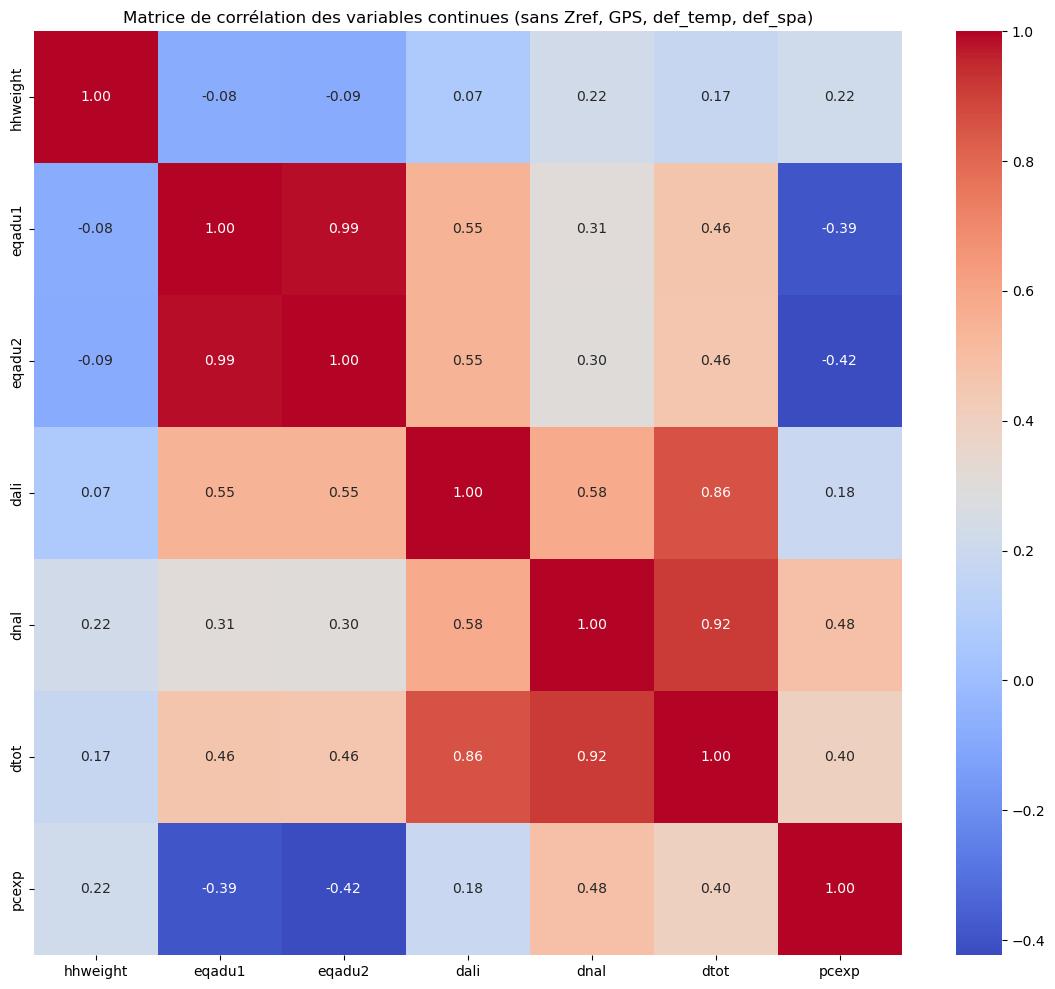

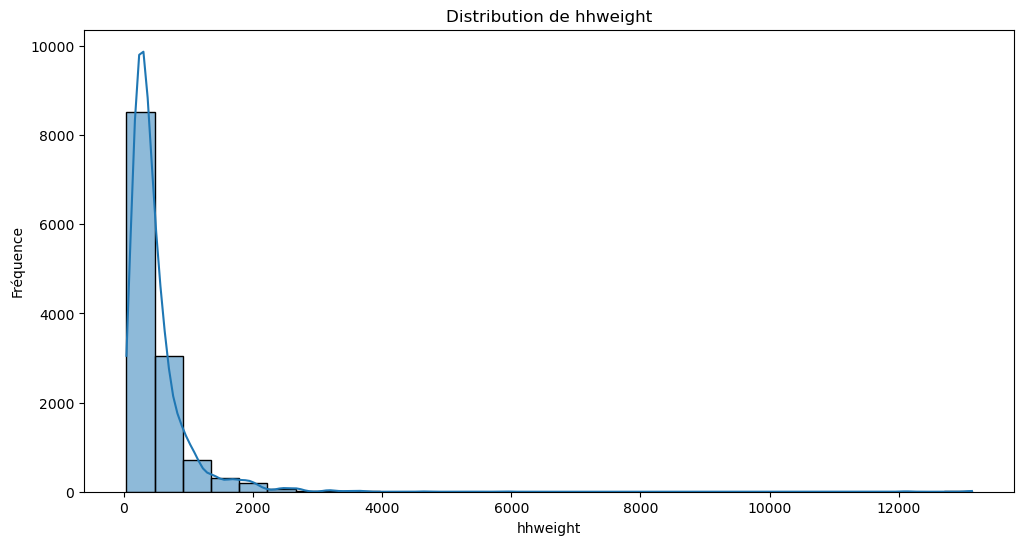

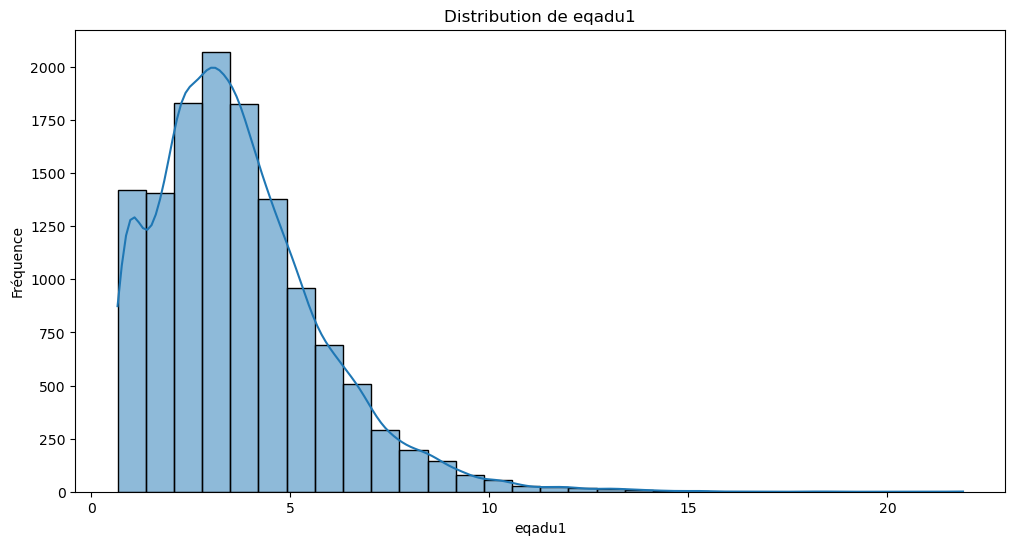

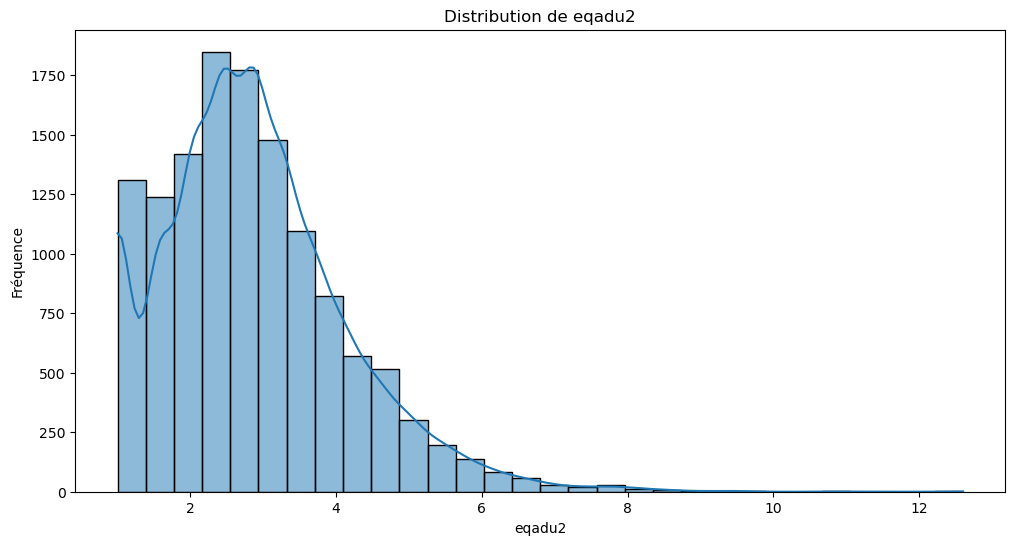

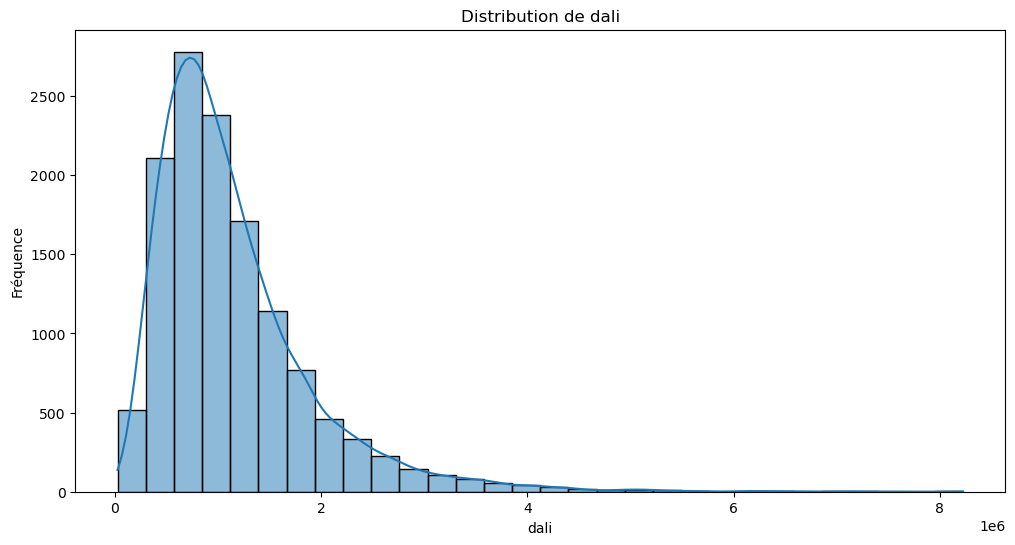

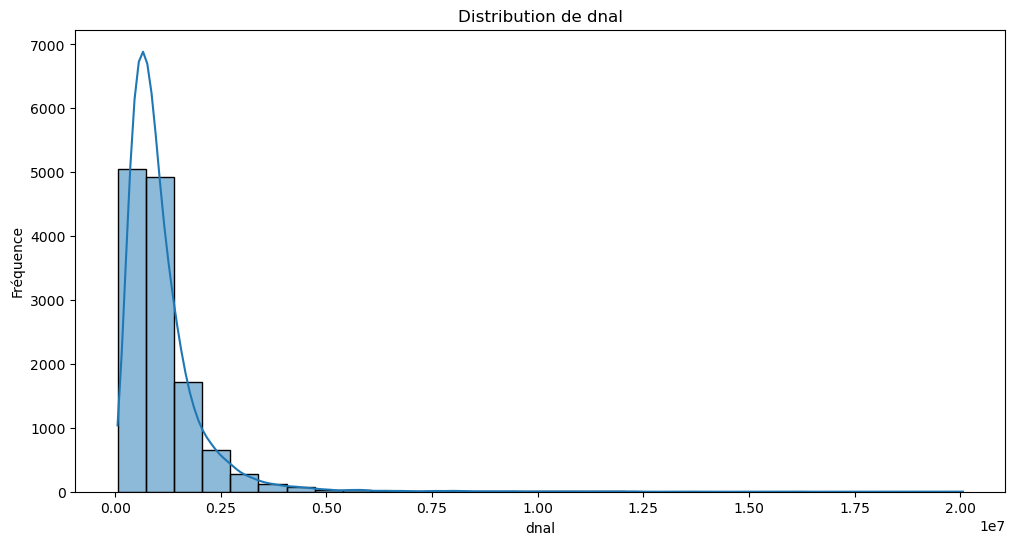

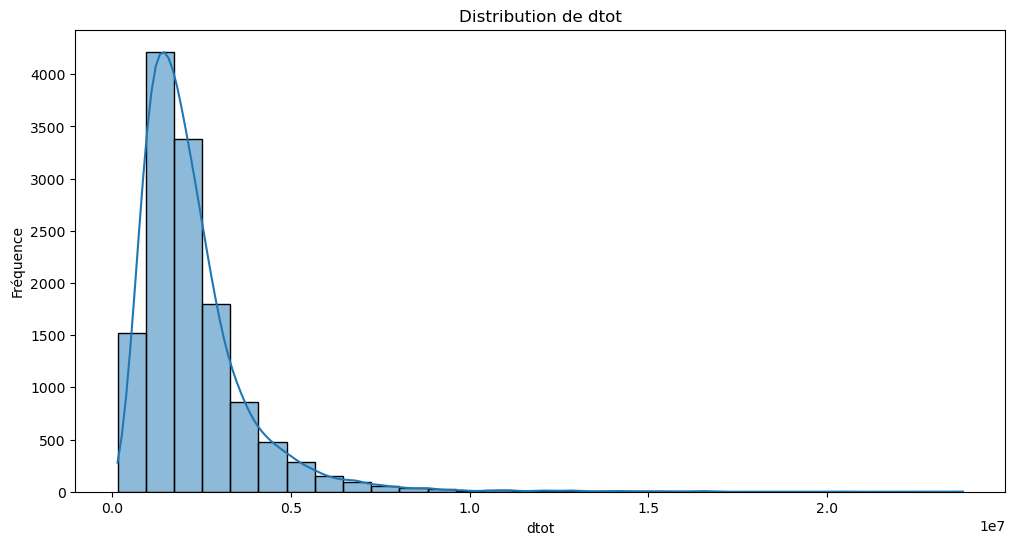

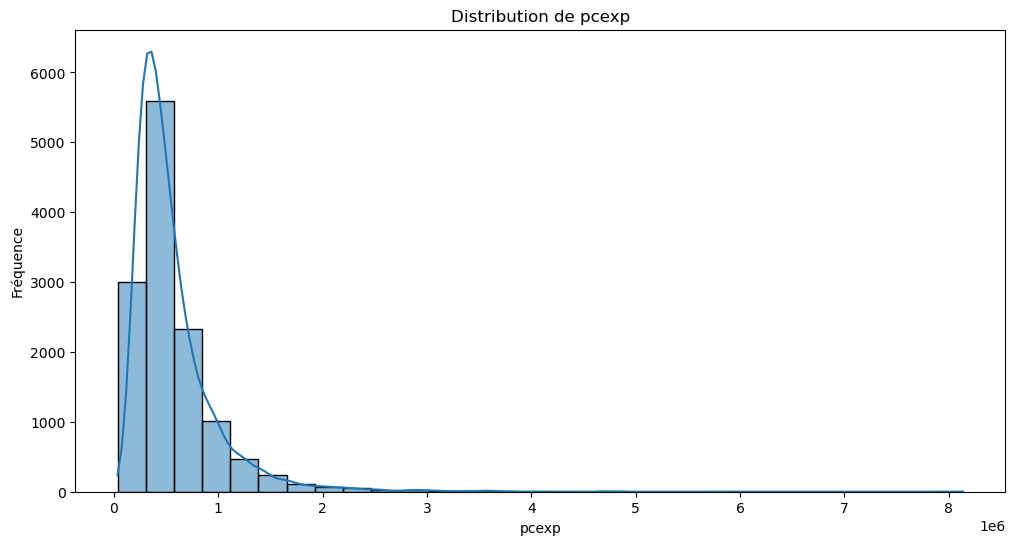

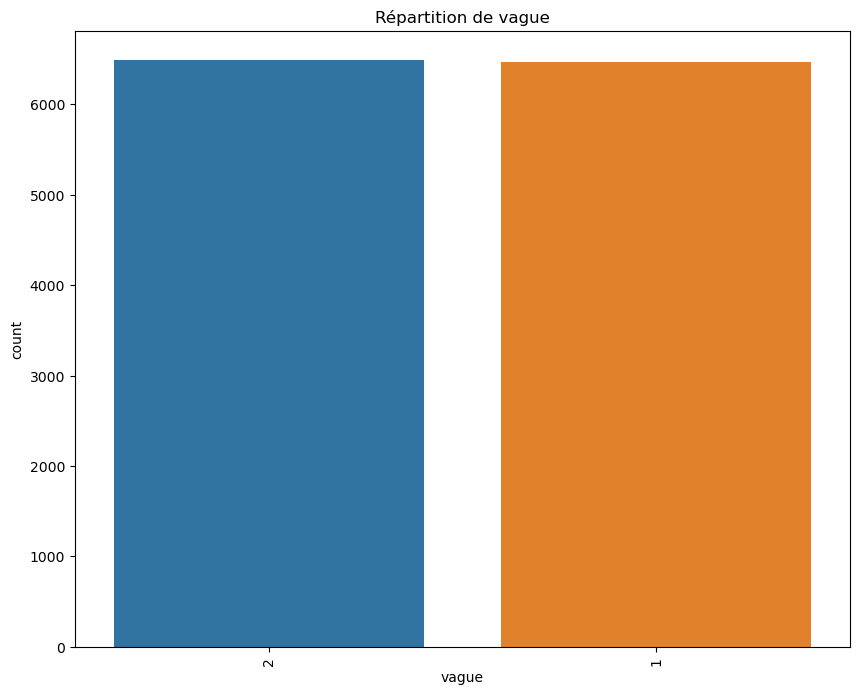

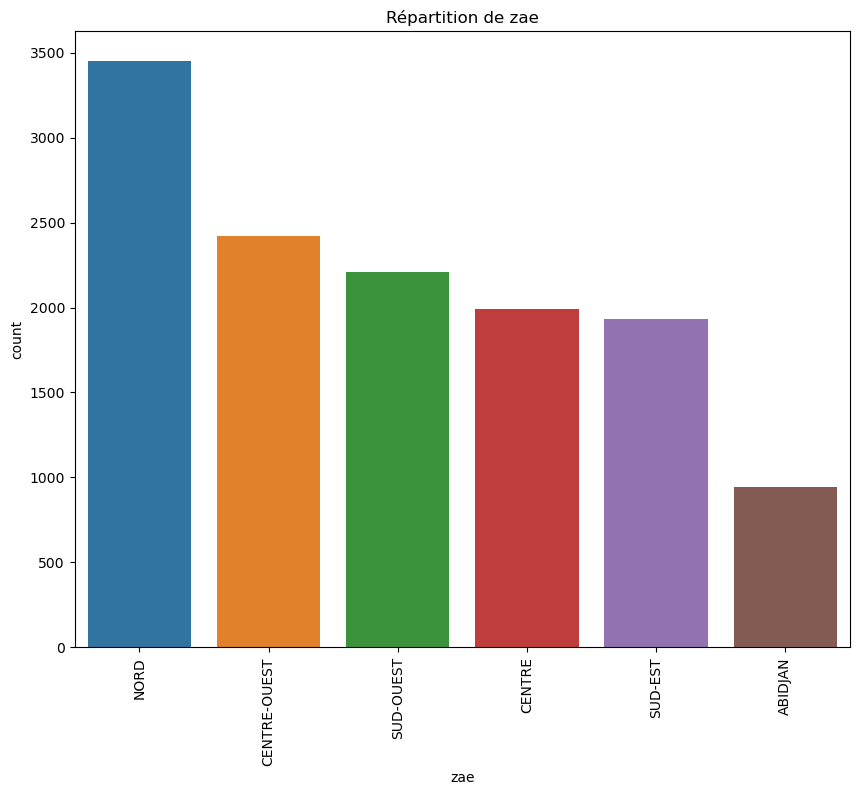

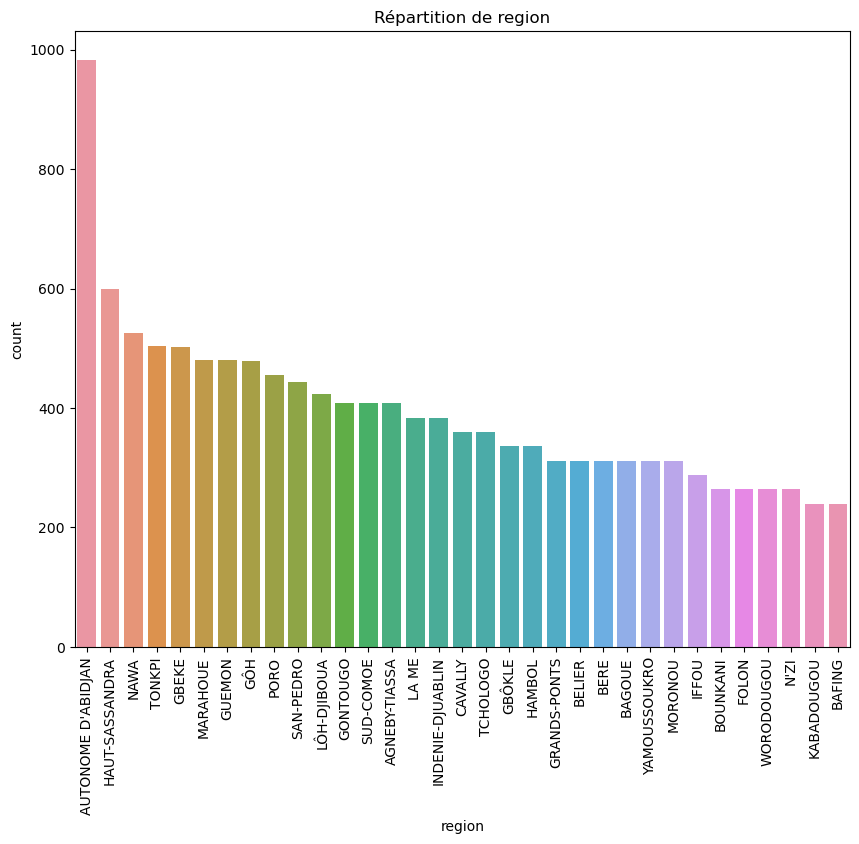

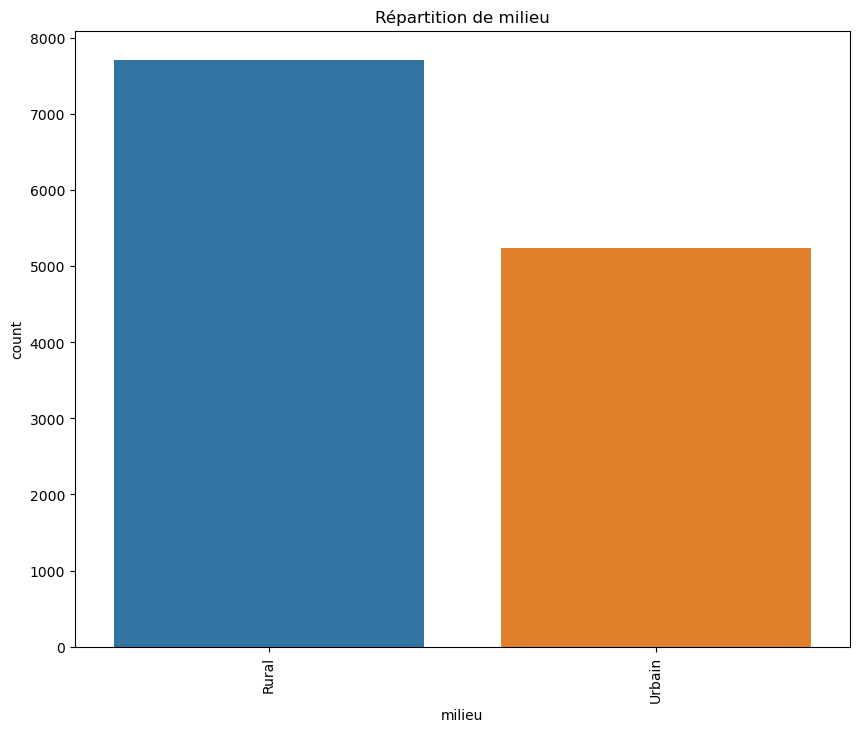

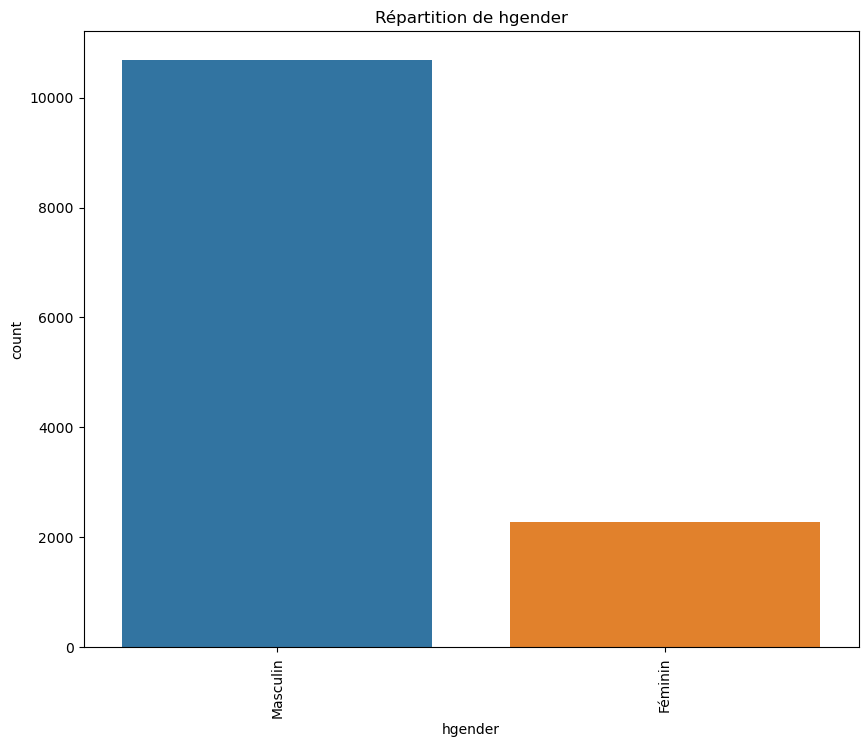

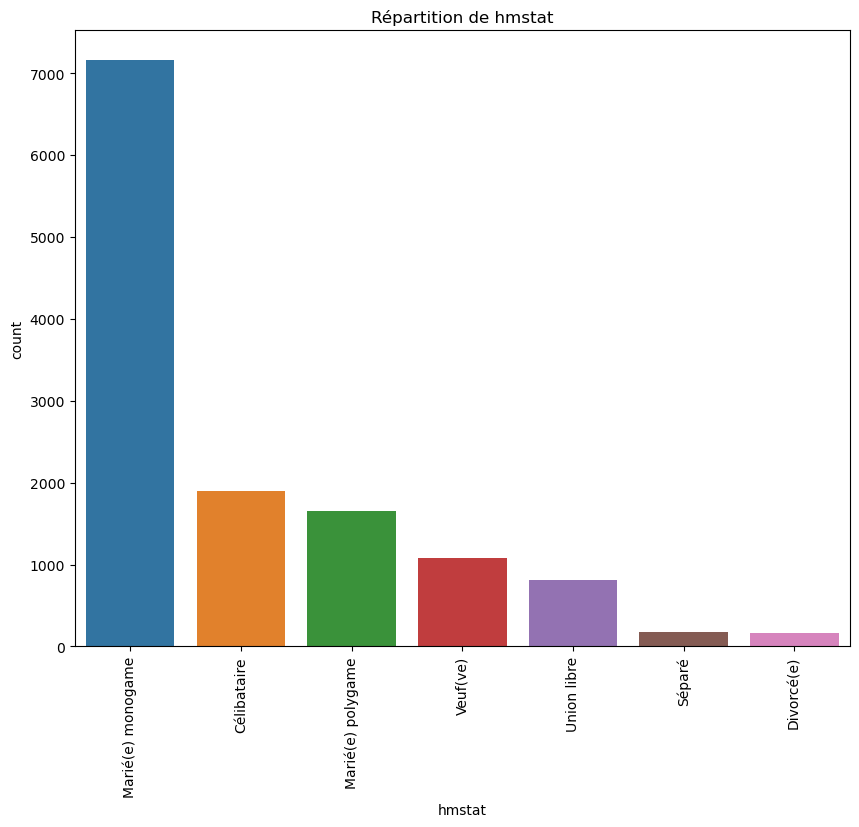

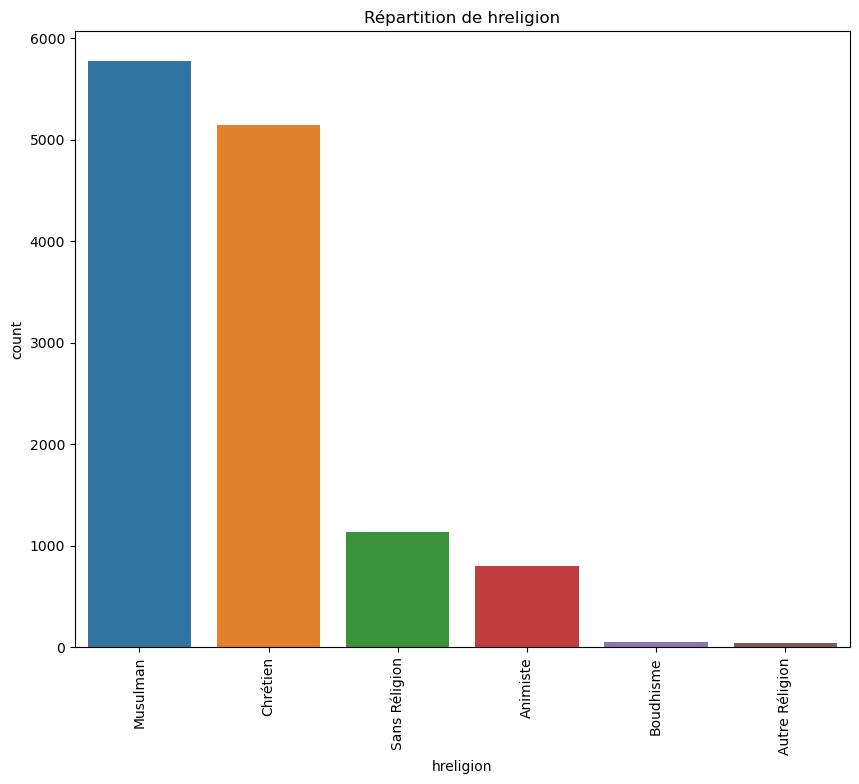

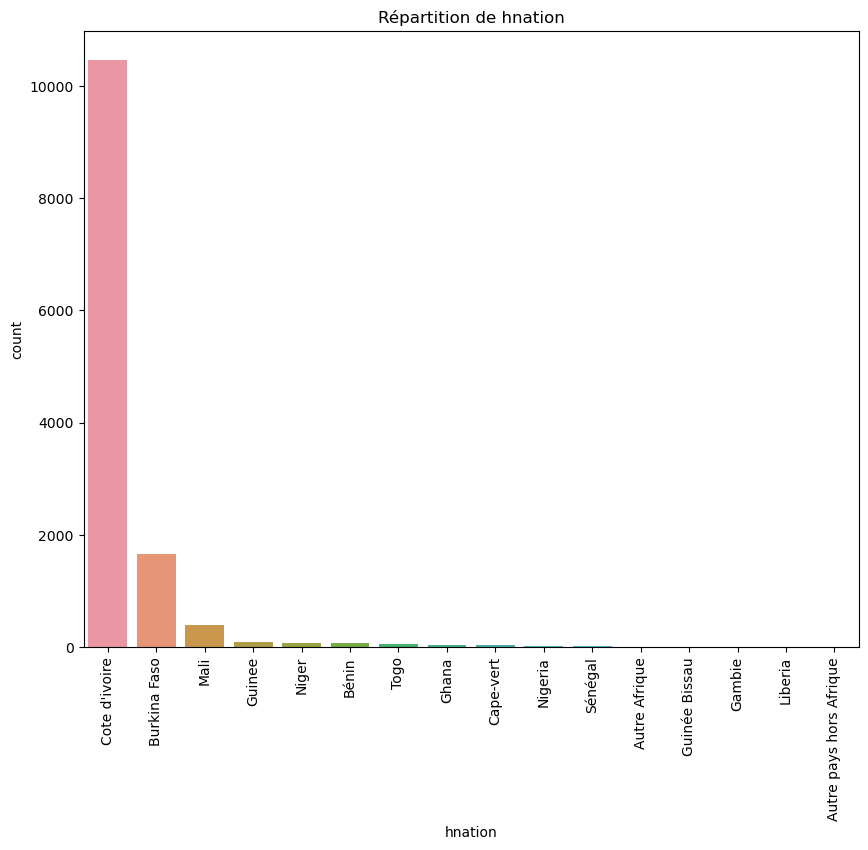

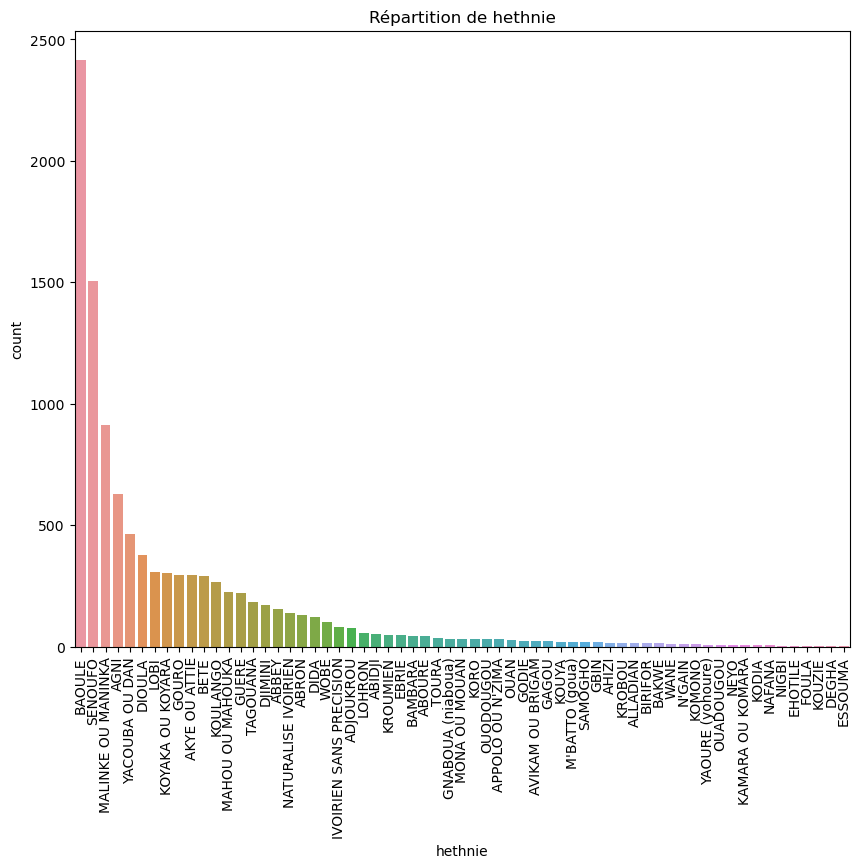

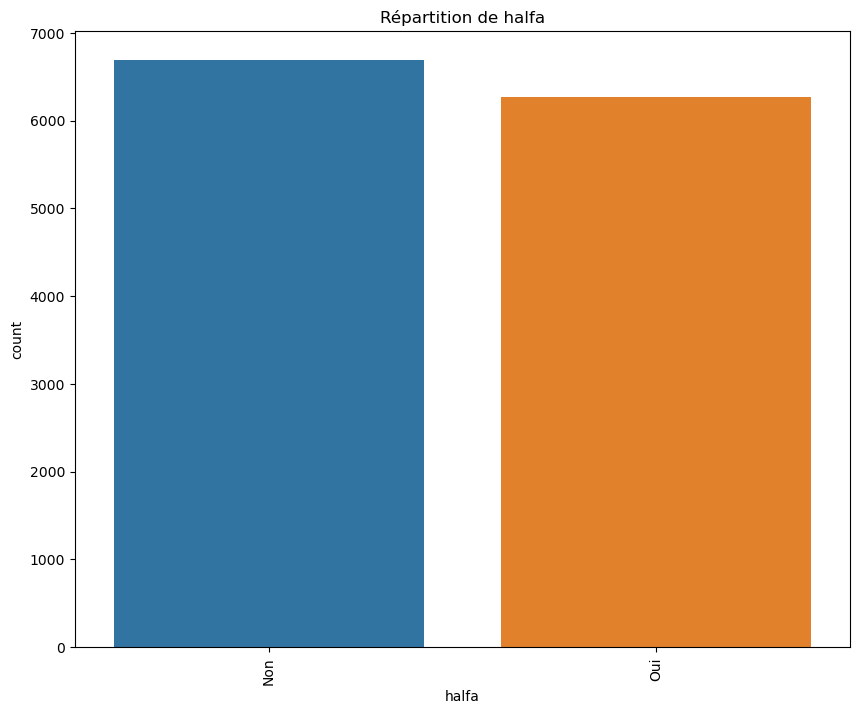

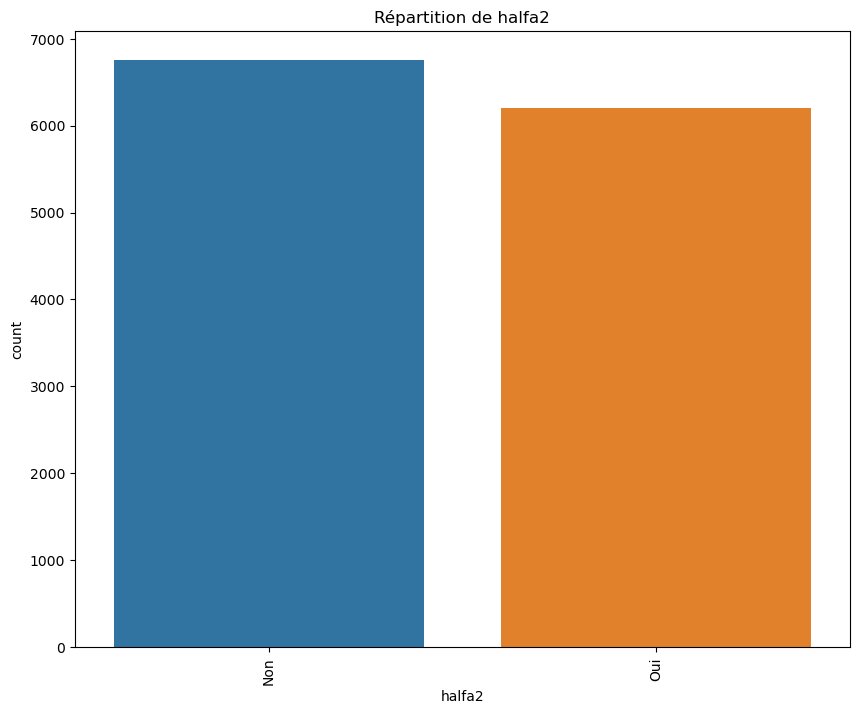

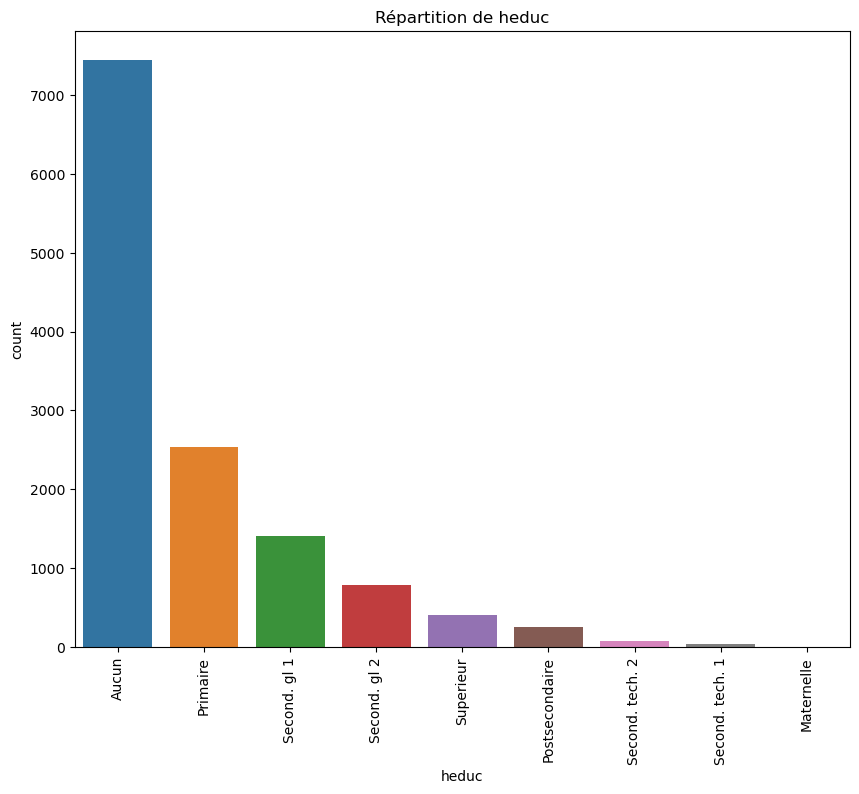

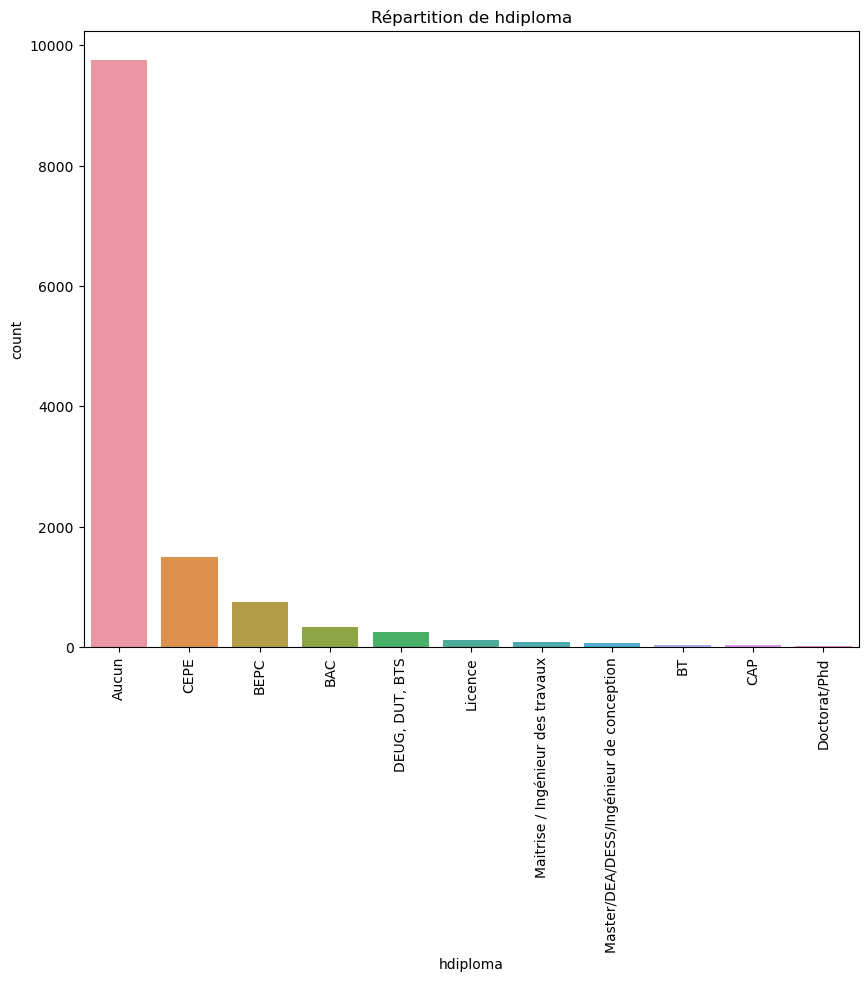

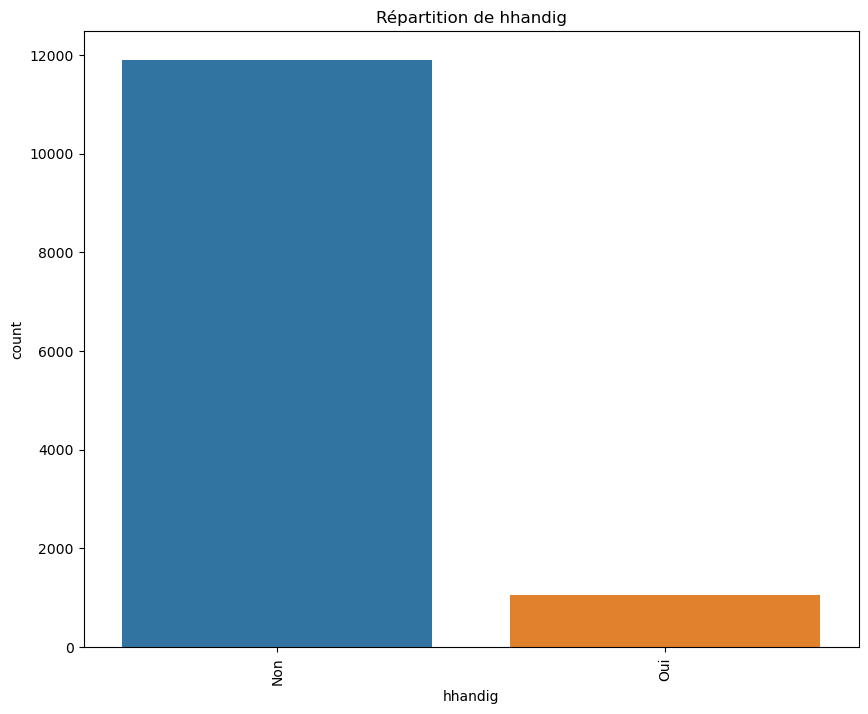

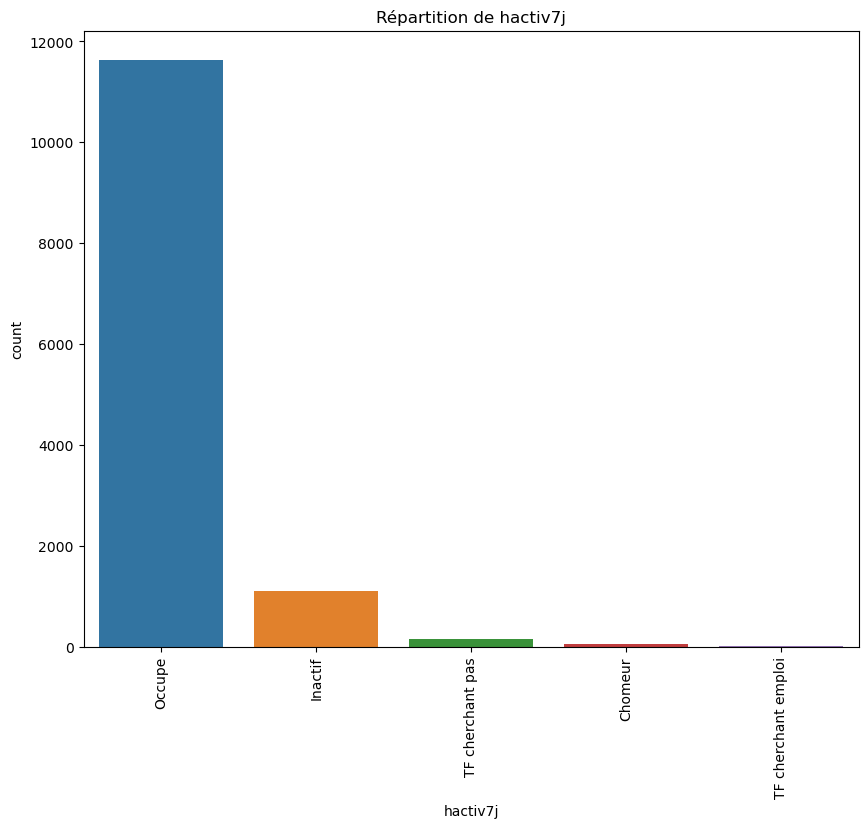

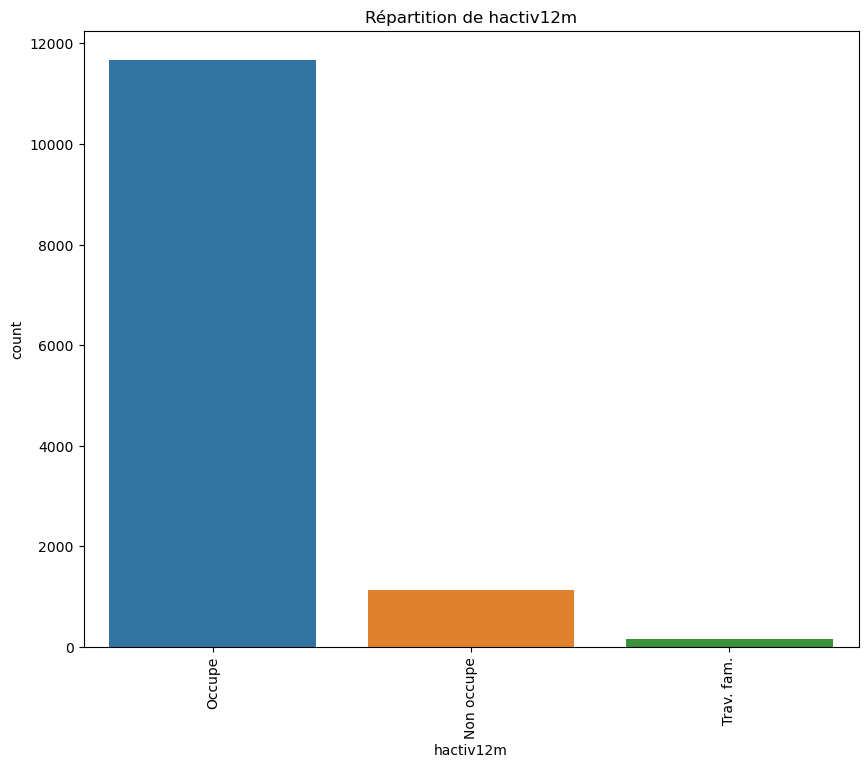

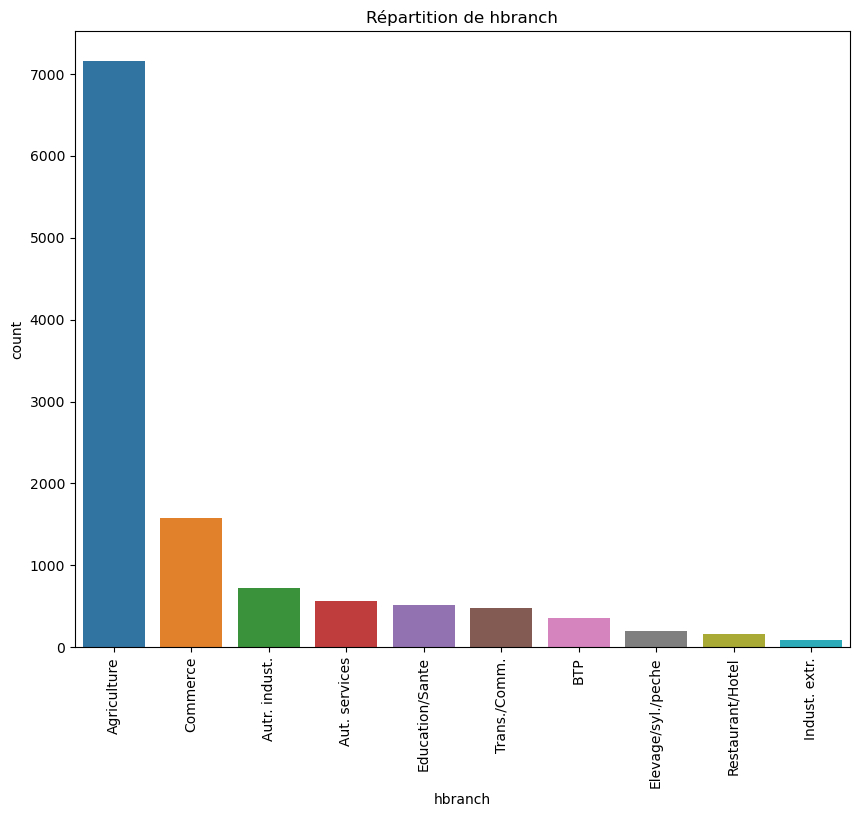

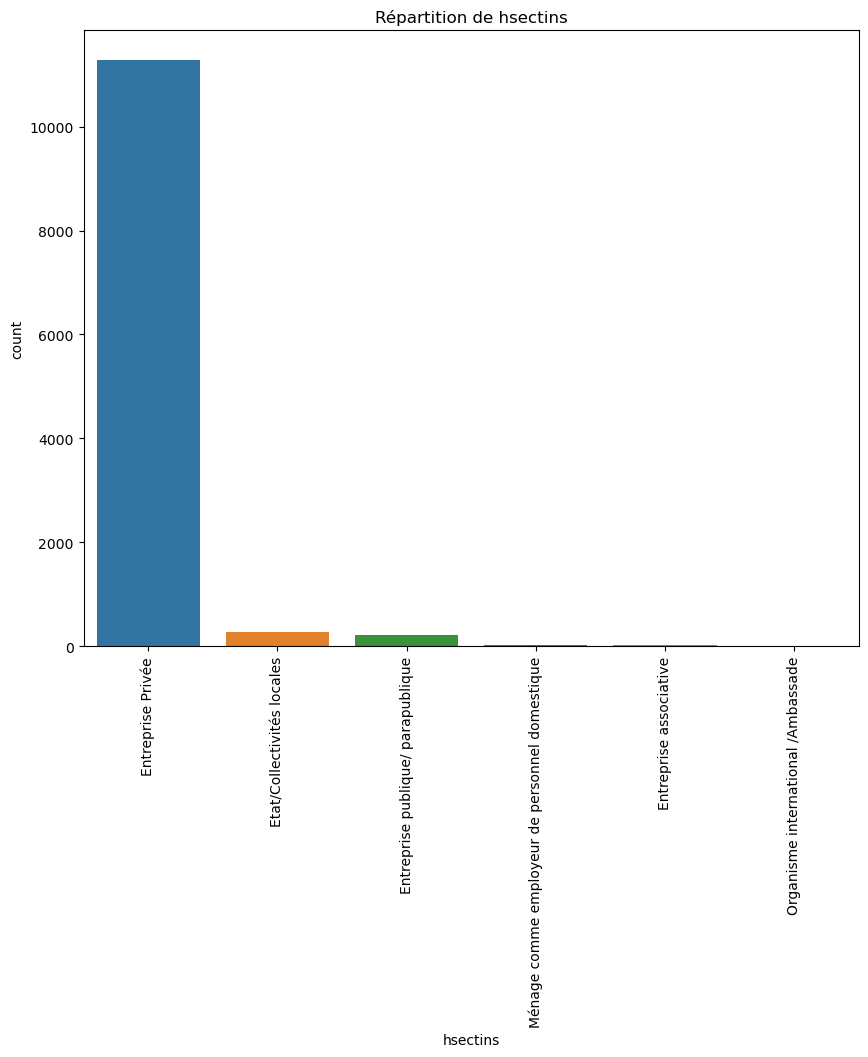

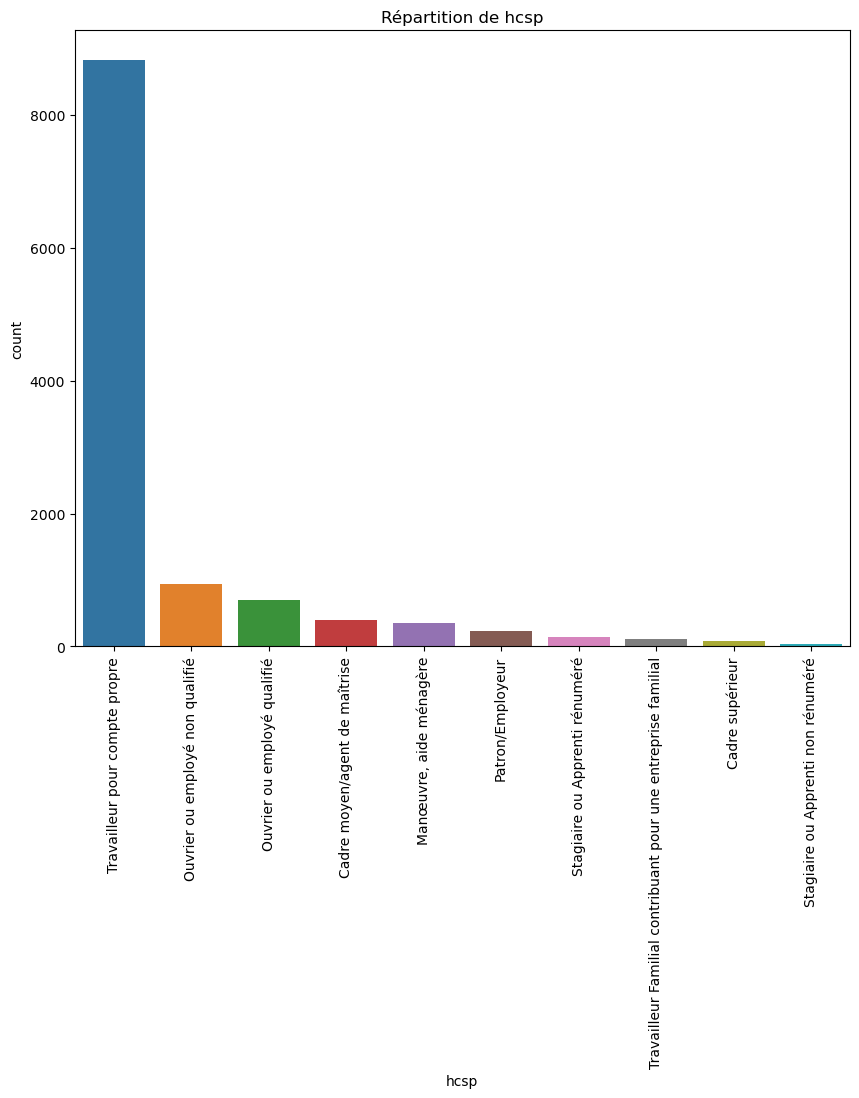

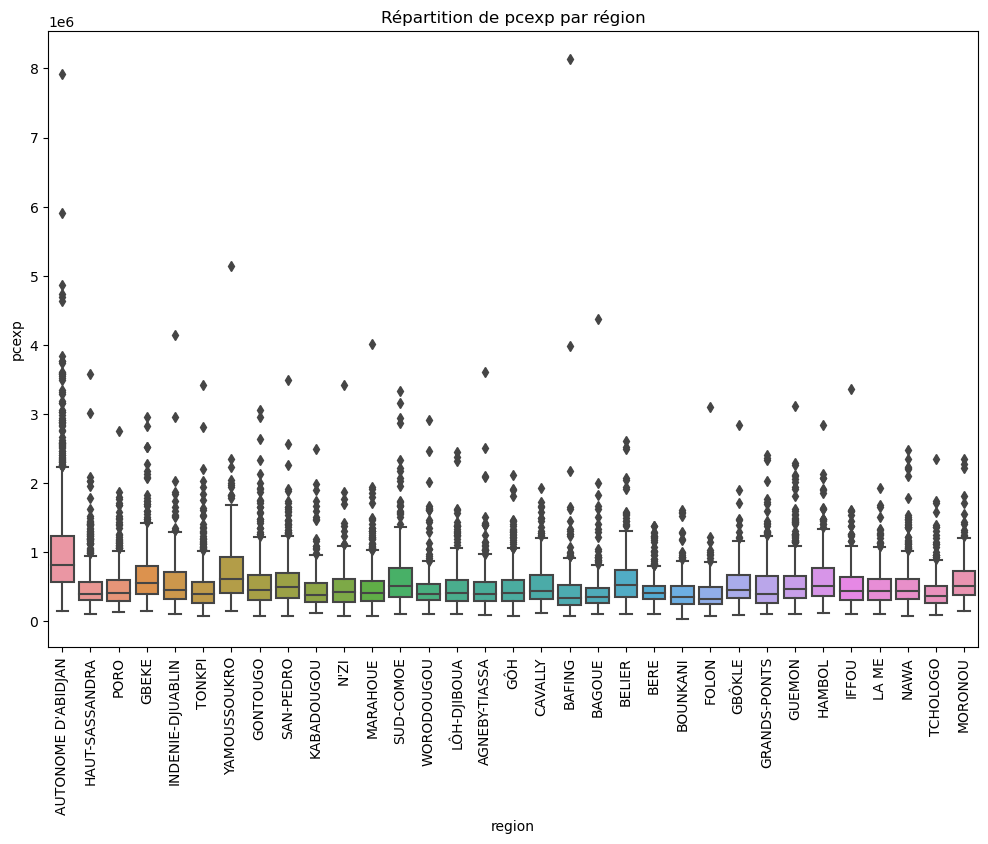

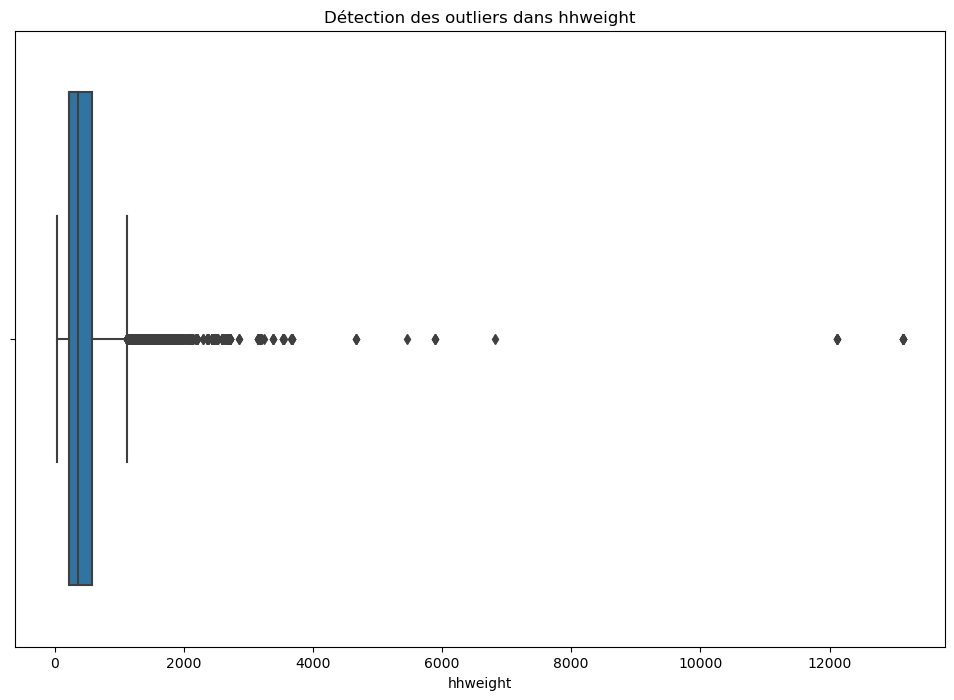

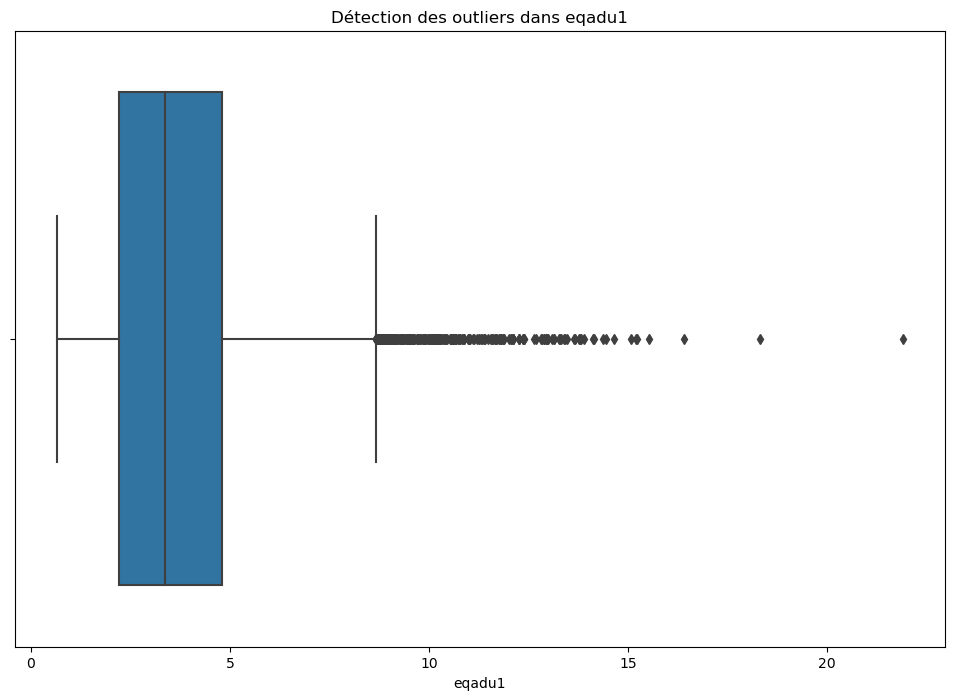

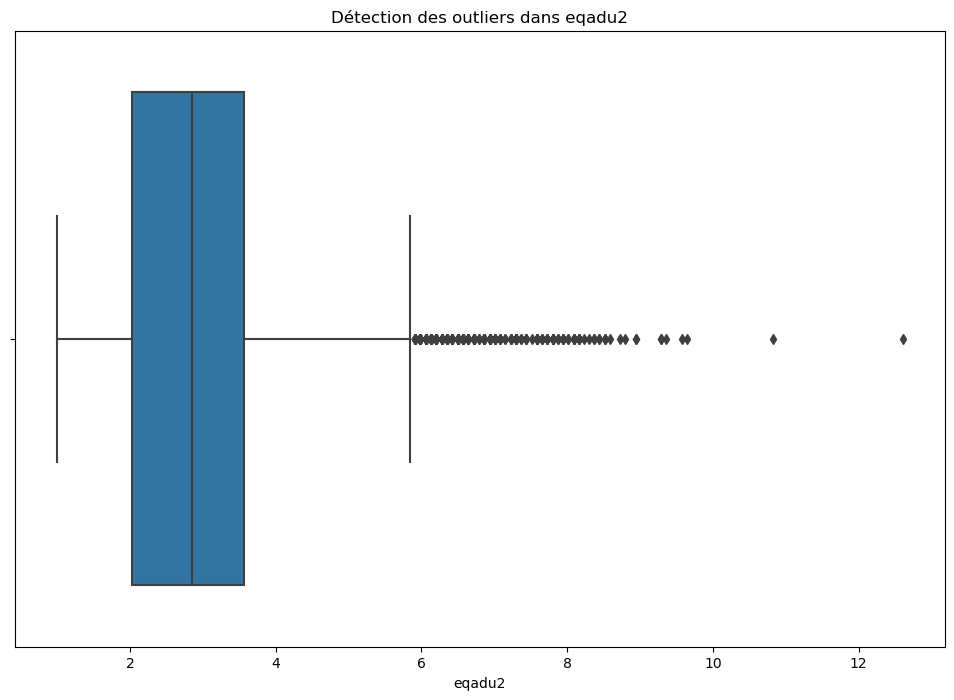

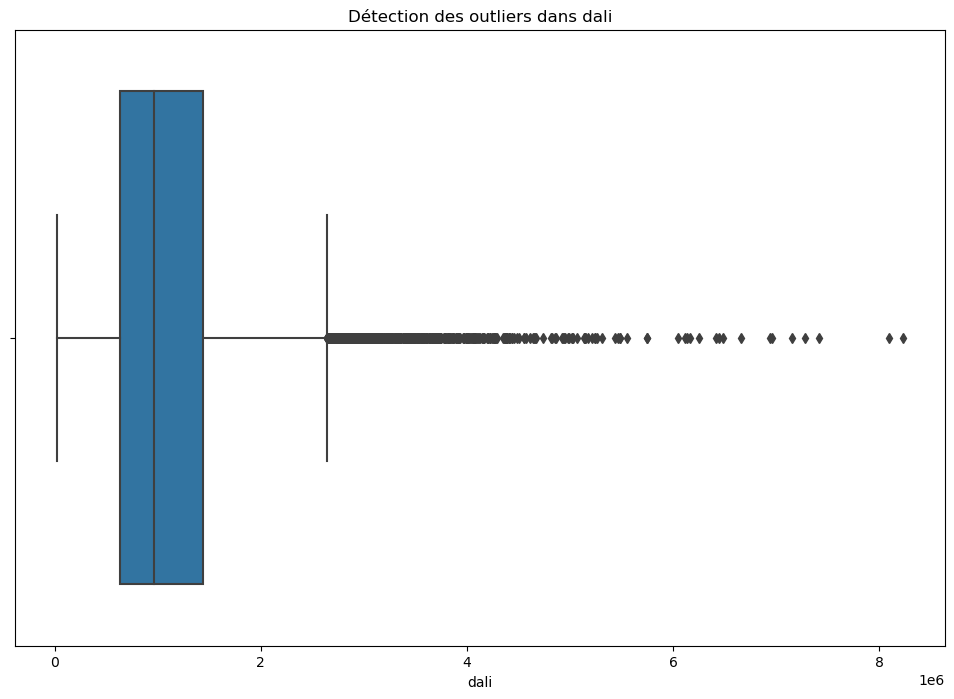

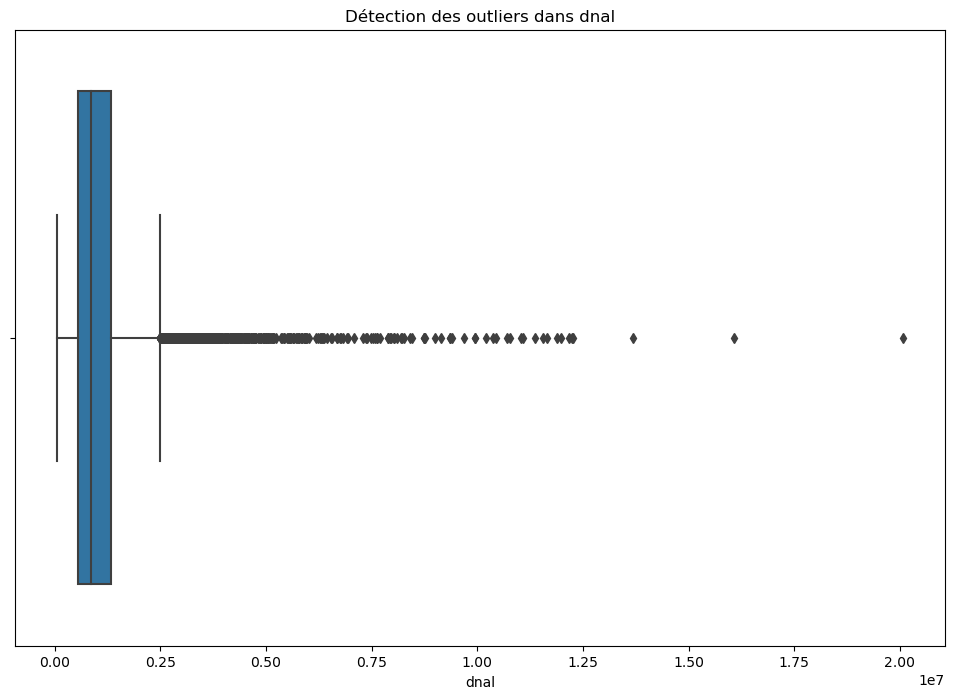

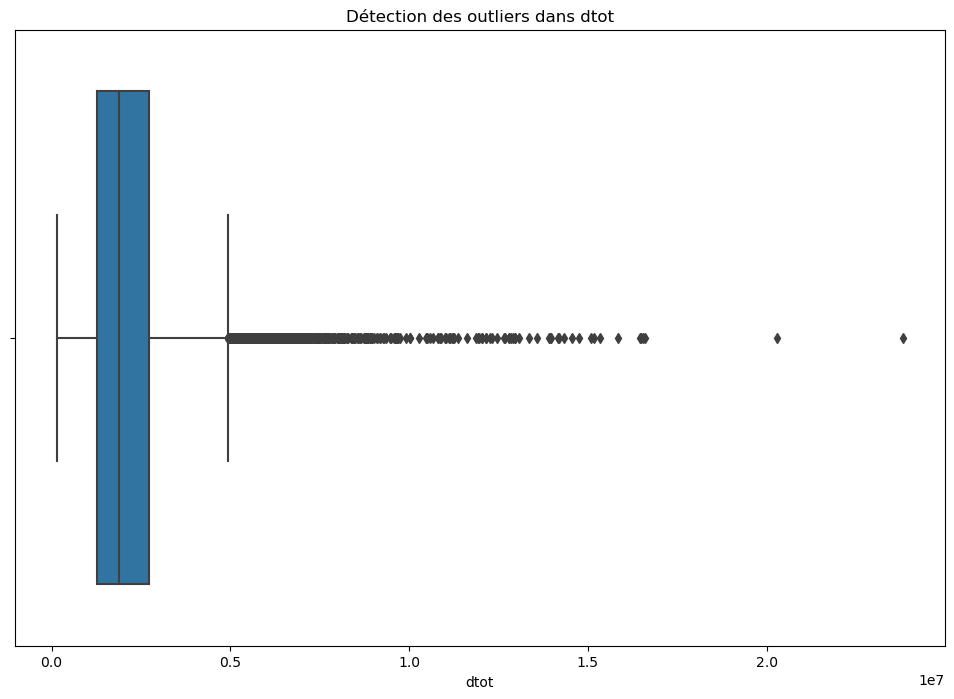

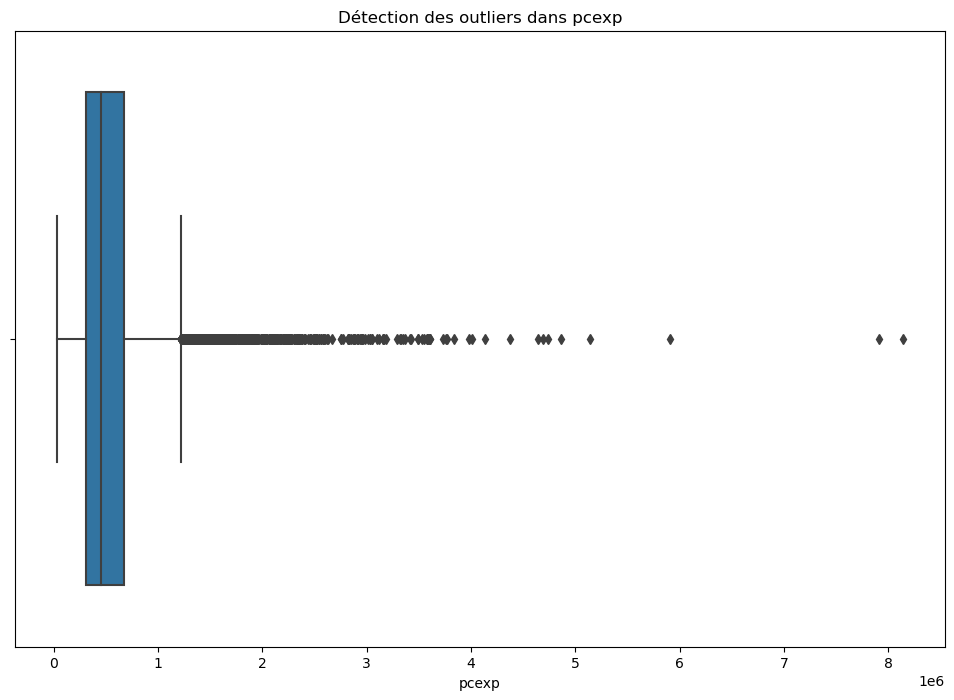

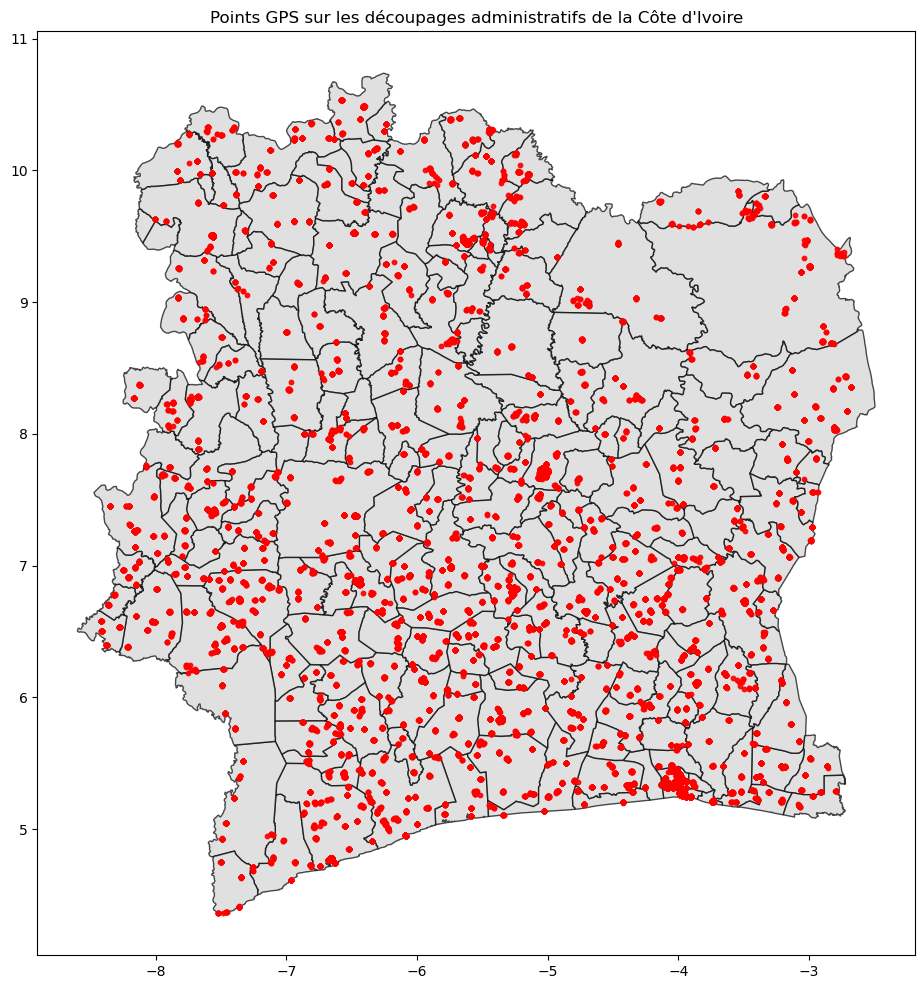

In [19]:
# Mettre à jour les types des variables spécifiques
merged_df_cleaned['grappe'] = merged_df_cleaned['grappe'].astype('category')
merged_df_cleaned['vague'] = merged_df_cleaned['vague'].astype('category')
merged_df_cleaned['year'] = merged_df_cleaned['year'].astype('category')
merged_df_cleaned['hhid'] = merged_df_cleaned['hhid'].astype(str)  # hhid est un numéro d'identification du ménage

# Aperçu des données
print("Aperçu des premières lignes :")
print(merged_df_cleaned.head())

# 1. Analyse des valeurs manquantes
missing_values = merged_df_cleaned.isnull().mean() * 100
print("\nPourcentage de valeurs manquantes :")
print(missing_values[missing_values > 0].sort_values(ascending=False))

# 2. Statistiques descriptives pour les variables continues
print("\nRésumé statistique des variables continues :")
continuous_columns = merged_df_cleaned.select_dtypes(include=['float64', 'float32']).columns
continuous_columns = [col for col in continuous_columns if col not in ['gps__longitude', 'gps__latitude', 'zref', 'def_temp', 'def_spa']]
print(merged_df_cleaned[continuous_columns].describe())

# 3. Corrélations entre les variables continues
print("\nMatrice de corrélation :")
correlation_matrix = merged_df_cleaned[continuous_columns].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de corrélation des variables continues (sans Zref, GPS, def_temp, def_spa)")
plt.show()

# 4. Distribution des variables continues
for col in continuous_columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(merged_df_cleaned[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

# 5. Répartition des variables catégoriques
categorical_columns = [col for col in merged_df_cleaned.select_dtypes(include=['category', 'object']).columns if col not in ['country', 'year', 'hhid', 'grappe']]
for col in categorical_columns:
    plt.figure(figsize=(10, 8))
    sns.countplot(data=merged_df_cleaned, x=col, order=merged_df_cleaned[col].value_counts().index)
    plt.title(f"Répartition de {col}")
    plt.xticks(rotation=90)
    plt.show()

# 6. Relation entre variables catégoriques et continues
if 'region' in merged_df_cleaned.columns and 'pcexp' in merged_df_cleaned.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=merged_df_cleaned, x='region', y='pcexp')
    plt.title("Répartition de pcexp par région")
    plt.xticks(rotation=90)
    plt.show()

# 7. Détection des outliers
for col in continuous_columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=merged_df_cleaned, x=col)
    plt.title(f"Détection des outliers dans {col}")
    plt.xlabel(col)
    plt.show()

# 8. Visualisation géographique des points GPS
if 'gps__latitude' in merged_df_cleaned.columns and 'gps__longitude' in merged_df_cleaned.columns:
    # Créer une GeoDataFrame avec les coordonnées GPS
    geometry = [Point(xy) for xy in zip(merged_df_cleaned['gps__longitude'], merged_df_cleaned['gps__latitude'])]
    geo_df = gpd.GeoDataFrame(merged_df_cleaned, geometry=geometry, crs="EPSG:4326")  # Système WGS84

    # Charger les découpages administratifs de la Côte d'Ivoire
    gadm_path = r'D:\wealth_predict_2021\data\downloaded\gadm41_CIV_4.json'
    civ = gpd.read_file(gadm_path)

    # Tracer les points sur la carte des découpages administratifs
    fig, ax = plt.subplots(figsize=(12, 12))
    civ.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)
    geo_df.plot(ax=ax, markersize=10, color='red', alpha=0.9)
    plt.title("Points GPS sur les découpages administratifs de la Côte d'Ivoire")
    plt.show()


##### calcul du taux de pauvreté

In [20]:
import pandas as pd

# Supposons que `merged_df_cleaned` est votre DataFrame contenant les colonnes nécessaires

# Calcul intermédiaire pour chaque ménage
merged_df_cleaned['weighted_poverty'] = merged_df_cleaned['hhsize'] * merged_df_cleaned['hhweight'] * merged_df_cleaned['pcexp_binaire']
merged_df_cleaned['total_weight'] = merged_df_cleaned['hhsize'] * merged_df_cleaned['hhweight']

# Calcul du taux de pauvreté réel
total_weighted_poverty = merged_df_cleaned['weighted_poverty'].sum()
total_weight = merged_df_cleaned['total_weight'].sum()
poverty_rate = total_weighted_poverty / total_weight

# Affichage du résultat
print(f"Taux de pauvreté réel : {poverty_rate:.2%}")
print(f"Taux de pauvreté réel arrondi : {poverty_rate:.1%}")



Taux de pauvreté réel : 37.46%
Taux de pauvreté réel arrondi : 37.5%


C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\2780417484.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['weighted_poverty'] = merged_df_cleaned['hhsize'] * merged_df_cleaned['hhweight'] * merged_df_cleaned['pcexp_binaire']
C:\Users\k.kone\AppData\Local\Temp\ipykernel_22732\2780417484.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_cleaned['total_weight'] = merged_df_cleaned['hhsize'] * merged_df_cleaned['hhweight']
